# Surrogate model design — pooling x architecture sweep

Explore readouts over **per-residue** ESM-2 embeddings for predicting FP spectra. We try **4 poolings**
(mean / min / max / std) x **2 architectures**:

- **MLP**: pool the residue embeddings -> MLP head.
- **CNN**: 1D-conv over the residue sequence -> pool -> head.

Performance is reported on **train and validation only** (the test split is left untouched to avoid peeking;
all model decisions should be made from val). Everything is knob-driven so you can try variations.

## 0. Setup, data, per-residue ESM-2 embeddings (cached)

In [1]:
import csv, os, time
import numpy as np, torch, torch.nn as nn, esm
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32)
grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EXM=np.array([float(r["ex_max"]) for r in rows]); EMM=np.array([float(r["em_max"]) for r in rows])
sur=np.array([r["surrogate_split"] for r in rows])
seqs=[None]*N; h=None
for line in open(os.path.join(TD,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
m={b:np.where(sur==b)[0] for b in("train","val","test")}
print("device",dev,"| surrogate",{b:len(v) for b,v in m.items()})

device mps | surrogate {'train': 317, 'val': 68, 'test': 68}


In [2]:
# per-residue layer-33 embeddings -> cache fp16 (N,Lmax,1280) + lengths
RP=os.path.join(TD,"esm_residue_fp16.npy"); LP=os.path.join(TD,"esm_residue_len.npy")
if os.path.exists(RP) and np.load(LP).shape[0]==N:
    H=np.load(RP); Ls=np.load(LP); print("loaded per-residue cache", H.shape)
else:
    model,alphabet=esm.pretrained.esm2_t33_650M_UR50D(); model=model.eval().to(dev)
    for p in model.parameters(): p.requires_grad_(False)
    bc=alphabet.get_batch_converter(); Lmax=max(len(s) for s in seqs)
    H=np.zeros((N,Lmax,1280),dtype=np.float16); Ls=np.zeros(N,dtype=np.int64); t=time.time()
    with torch.no_grad():
        for i in range(0,N,16):
            ch=seqs[i:i+16]; _,_,tk=bc([(f"s{j}",s) for j,s in enumerate(ch)]); tk=tk.to(dev)
            reps=model(tk,repr_layers=[33])["representations"][33]
            for j,s in enumerate(ch):
                n=len(s); H[i+j,:n]=reps[j,1:1+n].float().cpu().numpy().astype(np.float16); Ls[i+j]=n
    np.save(RP,H); np.save(LP,Ls); print(f"cached per-residue {H.shape} in {time.time()-t:.0f}s")
Lmax=H.shape[1]; Ht=torch.tensor(H); ar=torch.arange(Lmax)
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),torch.tensor(Y[b]).to(dev)

loaded per-residue cache (453, 476, 1280)


## 1. Masked pooling + model (MLP / CNN) + train/eval

`masked_pool` reduces over valid residues (mean/min/max/std). `SpectrumNet` is MLP (pool the raw embeddings)
or CNN (conv over residues, then pool). The pooling is the shared residue-reduction.

In [3]:
def masked_pool(x, mask, kind):                 # x:(B,L,C) mask:(B,L) bool
    mk = mask.unsqueeze(-1)
    cnt = mk.sum(1).clamp(min=1)
    mean = (x*mk).sum(1)/cnt
    if kind=="mean": return mean
    if kind=="max":  return x.masked_fill(~mk, float("-inf")).max(1).values
    if kind=="min":  return x.masked_fill(~mk, float("inf")).min(1).values
    if kind=="std":
        var = (((x-mean.unsqueeze(1))**2)*mk).sum(1)/cnt
        return torch.sqrt(var+1e-8)
    raise ValueError(kind)

class SpectrumNet(nn.Module):
    def __init__(self, pool, use_cnn, d_in=1280, conv_ch=128, k=5, hidden=256, nl=2, drop=0.2, out=2*G):
        super().__init__(); self.pool=pool; self.use_cnn=use_cnn
        if use_cnn:
            self.conv=nn.Sequential(nn.Conv1d(d_in,conv_ch,k,padding=k//2), nn.ReLU(),
                                    nn.Conv1d(conv_ch,conv_ch,k,padding=k//2), nn.ReLU())
            feat=conv_ch
        else:
            self.conv=None; feat=d_in
        L=[nn.Linear(feat,hidden), nn.ReLU()]
        for _ in range(nl-1): L+=[nn.Dropout(drop), nn.Linear(hidden,hidden), nn.ReLU()]
        L+=[nn.Linear(hidden,out)]; self.head=nn.Sequential(*L)
    def forward(self, Hb, mask):
        x = Hb
        if self.use_cnn:
            x = self.conv(x.transpose(1,2)).transpose(1,2)     # (B,L,conv_ch)
        return self.head(masked_pool(x, mask, self.pool))

In [4]:
def exem(S): return grid[np.argmax(S[:,:G],1)], grid[np.argmax(S[:,G:],1)]
def eval_split(net, split):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,yb in batches(m[split]): ps.append(net(Hb,mk).cpu().numpy())
    P=np.concatenate(ps); idx=m[split]; T=Y[idx]; ex,em=exem(P)
    return dict(mse=float(((P-T)**2).mean()),
                ex_mae=float(np.abs(ex-EXM[idx]).mean()),
                em_mae=float(np.abs(em-EMM[idx]).mean()))

def train_eval(pool, use_cnn, epochs, seed=0):
    torch.manual_seed(seed)
    net=SpectrumNet(pool, use_cnn, conv_ch=CONV_CH, k=KSIZE, hidden=HIDDEN, nl=NL, drop=DROP).to(dev)
    opt=torch.optim.Adam(net.parameters(), LR, weight_decay=WD); lf=nn.MSELoss()
    best=None
    for ep in range(epochs):
        net.train()
        for Hb,mk,yb in batches(m["train"], shuffle=True):
            opt.zero_grad(); lf(net(Hb,mk),yb).backward(); opt.step()
        vm=eval_split(net,"val")                       # select by best val
        if best is None or vm["mse"]<best["val"]["mse"]:
            best={"val":vm, "train":eval_split(net,"train"), "ep":ep}
    return best

## 2. Sweep: 4 poolings x {MLP, CNN}

Knobs below. Reports train & val MSE and emission-max MAE at each model's best-val epoch.

In [5]:
EPOCHS=150; CONV_CH=128; KSIZE=5; HIDDEN=256; NL=2; DROP=0.2; LR=1e-3; WD=1e-4
POOLS=["mean","min","max","std"]

base = Y[m["train"]].mean(0, keepdims=True)
base_val = float(((np.repeat(base,len(m["val"]),0)-Y[m["val"]])**2).mean())
print(f"baseline (mean spectrum) val MSE: {base_val:.5f}\n")

table=[]
t0=time.time()
for arch,use_cnn in (("MLP",False),("CNN",True)):
    for pool in POOLS:
        r=train_eval(pool, use_cnn, EPOCHS)
        table.append((arch,pool,r))
        print(f"{arch} {pool:4s} @ep{r['ep']:3d} | train MSE {r['train']['mse']:.5f} "
              f"val MSE {r['val']['mse']:.5f} | train emMAE {r['train']['em_mae']:5.1f} "
              f"val emMAE {r['val']['em_mae']:5.1f}")
print(f"\nswept {len(table)} models in {time.time()-t0:.0f}s")

baseline (mean spectrum) val MSE: 0.03608



MLP mean @ep  1 | train MSE 0.05010 val MSE 0.03720 | train emMAE  51.3 val emMAE  28.7


MLP min  @ep 18 | train MSE 0.03425 val MSE 0.03400 | train emMAE  26.2 val emMAE  29.6


MLP max  @ep 63 | train MSE 0.02886 val MSE 0.03461 | train emMAE  16.7 val emMAE  36.1


MLP std  @ep 22 | train MSE 0.04933 val MSE 0.03482 | train emMAE  51.8 val emMAE  29.7


CNN mean @ep  2 | train MSE 0.05090 val MSE 0.03714 | train emMAE  50.5 val emMAE  28.6


CNN min  @ep  1 | train MSE 0.05149 val MSE 0.03641 | train emMAE  51.4 val emMAE  29.0


CNN max  @ep  8 | train MSE 0.02898 val MSE 0.03495 | train emMAE  20.6 val emMAE  29.0


CNN std  @ep  3 | train MSE 0.05021 val MSE 0.03540 | train emMAE  52.1 val emMAE  30.1

swept 8 models in 300s


In [6]:
# summary table sorted by val MSE
print(f"{'arch':4s} {'pool':5s} {'train MSE':>9} {'val MSE':>8} {'train emMAE':>12} {'val emMAE':>10}")
for arch,pool,r in sorted(table, key=lambda x:x[2]["val"]["mse"]):
    print(f"{arch:4s} {pool:5s} {r['train']['mse']:9.5f} {r['val']['mse']:8.5f} "
          f"{r['train']['em_mae']:12.1f} {r['val']['em_mae']:10.1f}")
print(f"baseline val MSE {base_val:.5f}")

arch pool  train MSE  val MSE  train emMAE  val emMAE
MLP  min     0.03425  0.03400         26.2       29.6
MLP  max     0.02886  0.03461         16.7       36.1
MLP  std     0.04933  0.03482         51.8       29.7
CNN  max     0.02898  0.03495         20.6       29.0
CNN  std     0.05021  0.03540         52.1       30.1
CNN  min     0.05149  0.03641         51.4       29.0
CNN  mean    0.05090  0.03714         50.5       28.6
MLP  mean    0.05010  0.03720         51.3       28.7
baseline val MSE 0.03608


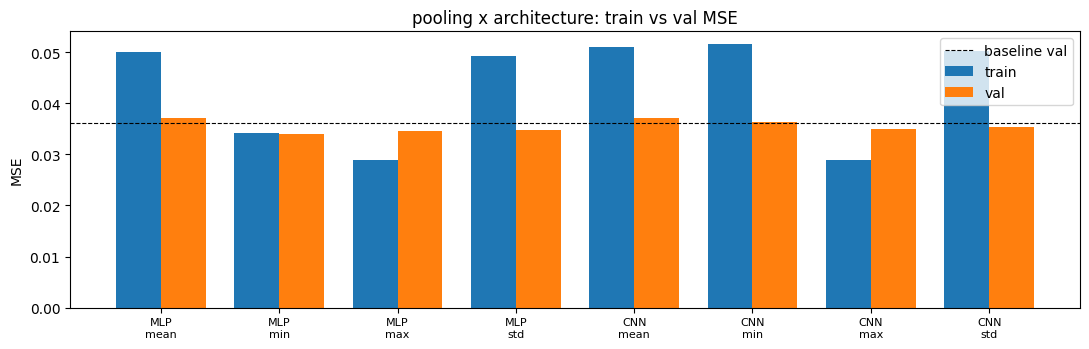

In [7]:
if HAVE_PLT:
    labels=[f"{a}\n{p}" for a,p,_ in table]
    tr=[r["train"]["mse"] for _,_,r in table]; va=[r["val"]["mse"] for _,_,r in table]
    x=np.arange(len(table)); w=0.38
    plt.figure(figsize=(11,3.6))
    plt.bar(x-w/2, tr, w, label="train"); plt.bar(x+w/2, va, w, label="val")
    plt.axhline(base_val, color="k", ls="--", lw=0.8, label="baseline val")
    plt.xticks(x, labels, fontsize=8); plt.ylabel("MSE"); plt.title("pooling x architecture: train vs val MSE")
    plt.legend(); plt.tight_layout(); plt.show()

## Notes

- **Train vs val gap = overfitting** per config; the test split is deliberately untouched here. Pick the
  readout/architecture on **val**, then evaluate test once (separately) when you commit.
- Tune the knobs (`CONV_CH`, `KSIZE`, `HIDDEN`, `DROP`, `WD`, `EPOCHS`) to explore. min/std are cheap extra
  views of the residue distribution; max tends to capture the few decisive (chromophore) residues.